In [1]:
# 1. Импорты, seed, устройство
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import STL10, VOCDetection
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import json

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Пути для сохранения артефактов
artifacts_dir = './artifacts'
figures_dir = os.path.join(artifacts_dir, 'figures')
os.makedirs(artifacts_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

Using device: cuda


## Часть A: классификация (STL10)

### Загрузка данных, трансформации и DataLoader

In [2]:
# Базовые трансформации для простой CNN
transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Аугментированные трансформации
transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Трансформации для ResNet (нормализация ImageNet)
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасета STL10
train_dataset_full = STL10(root='./data', split='train', download=True, transform=transform_base)
test_dataset = STL10(root='./data', split='test', download=True, transform=transform_base)

# Разделение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset_full, [train_size, val_size])

# Применяем нужные трансформации для каждого датасета (для экспериментов будем создавать отдельно)
# Сейчас создадим базовый train/val с базовыми трансформами
train_dataset_base = Subset(train_dataset_full, train_subset.indices)
val_dataset_base = Subset(train_dataset_full, val_subset.indices)
# Меняем трансформации у датасетов через переопределение dataset.dataset.transform
train_dataset_base.dataset.transform = transform_base
val_dataset_base.dataset.transform = transform_base
test_dataset.transform = transform_base

# Для аугментаций создадим отдельные датасеты
train_dataset_aug = Subset(train_dataset_full, train_subset.indices)
train_dataset_aug.dataset.transform = transform_aug
val_dataset_aug = Subset(train_dataset_full, val_subset.indices)
val_dataset_aug.dataset.transform = transform_base   # валидация без аугментаций

# Для ResNet
train_dataset_resnet = Subset(train_dataset_full, train_subset.indices)
train_dataset_resnet.dataset.transform = transform_resnet
val_dataset_resnet = Subset(train_dataset_full, val_subset.indices)
val_dataset_resnet.dataset.transform = transform_resnet
test_dataset_resnet = STL10(root='./data', split='test', download=True, transform=transform_resnet)

# DataLoaders
batch_size = 16
train_loader_base = DataLoader(train_dataset_base, batch_size=batch_size, shuffle=True)
val_loader_base = DataLoader(val_dataset_base, batch_size=batch_size, shuffle=False)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_base = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)
x, y = next(iter(train_loader_base))
print(f"Batch shape: {x.shape}, labels shape: {y.shape}")
def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Batch shape: torch.Size([16, 3, 224, 224]), labels shape: torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.7055321].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39626682..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40222222..1.7589979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4048292..1.7677125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.82].


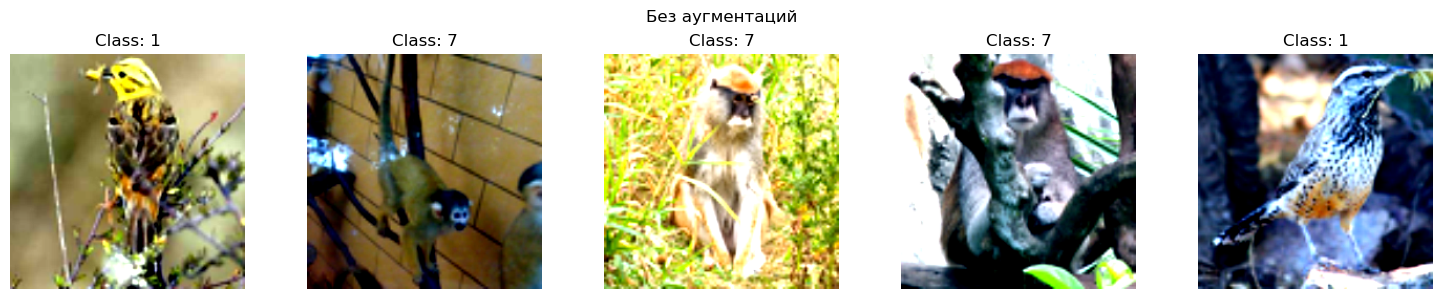

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.7851416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.132703..1.4278432].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5062746].


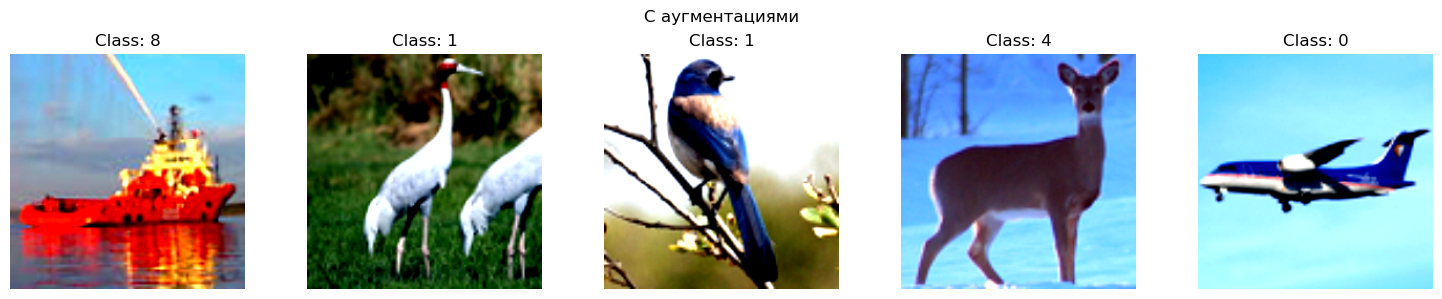

In [3]:
# Визуализация примеров и аугментаций
def show_images(images, labels, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i in range(5):
        img = images[i].permute(1,2,0).numpy()
        img = (img * 0.5 + 0.5)  # денормализация
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {labels[i].item()}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    return fig

# Примеры без аугментаций
images, labels = next(iter(train_loader_base))
fig = show_images(images, labels, "Без аугментаций")
fig.savefig(os.path.join(figures_dir, 'augmentations_preview.png'))
plt.show()

# Примеры с аугментациями
images_aug, labels_aug = next(iter(train_loader_aug))
fig = show_images(images_aug, labels_aug, "С аугментациями")
plt.show()

### Определение функций обучения и оценки

In [4]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, experiment_id):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
    return history, best_model_state, best_val_acc

# Сохранение истории в CSV (дополнительно)
def save_history(history, filename):
    df = pd.DataFrame(history)
    df.to_csv(filename, index=False)

### Эксперименты C1 - C4

Определим простую CNN архитектуру

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        # Адаптивный пулинг, чтобы всегда получать карту признаков 4x4
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(128 * 4 * 4, 256)   # 128*16 = 2048
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)          # размер (batch, 128, 4, 4)
        x = x.view(x.size(0), -1)          # (batch, 128*4*4)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
# C1: simple-cnn-base
print("=== C1: simple-cnn-base ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=lr)
history_c1, best_state_c1, best_val_acc_c1 = train_model(model_c1, train_loader_base, val_loader_base, criterion, optimizer_c1, num_epochs, device, 'C1')
print(f"C1 best val acc: {best_val_acc_c1:.4f}")
# Сохраняем историю
save_history(history_c1, os.path.join(artifacts_dir, 'history_C1.csv'))

=== C1: simple-cnn-base ===
Epoch 1/15 | Train Loss: 1.9135 Acc: 0.2757 | Val Loss: 1.6659 Acc: 0.3630
Epoch 2/15 | Train Loss: 1.6546 Acc: 0.3555 | Val Loss: 1.5083 Acc: 0.4280
Epoch 3/15 | Train Loss: 1.5735 Acc: 0.3940 | Val Loss: 1.4035 Acc: 0.4880
Epoch 4/15 | Train Loss: 1.5146 Acc: 0.4228 | Val Loss: 1.3855 Acc: 0.5060
Epoch 5/15 | Train Loss: 1.4608 Acc: 0.4527 | Val Loss: 1.4524 Acc: 0.4810
Epoch 6/15 | Train Loss: 1.4285 Acc: 0.4640 | Val Loss: 1.3727 Acc: 0.4910
Epoch 7/15 | Train Loss: 1.3937 Acc: 0.4748 | Val Loss: 1.2879 Acc: 0.5300
Epoch 8/15 | Train Loss: 1.3427 Acc: 0.4980 | Val Loss: 1.2853 Acc: 0.5530
Epoch 9/15 | Train Loss: 1.3190 Acc: 0.4985 | Val Loss: 1.2390 Acc: 0.5580
Epoch 10/15 | Train Loss: 1.2893 Acc: 0.5145 | Val Loss: 1.2188 Acc: 0.5650
Epoch 11/15 | Train Loss: 1.2597 Acc: 0.5280 | Val Loss: 1.1745 Acc: 0.5830
Epoch 12/15 | Train Loss: 1.2217 Acc: 0.5365 | Val Loss: 1.1882 Acc: 0.5850
Epoch 13/15 | Train Loss: 1.1881 Acc: 0.5593 | Val Loss: 1.1992 Acc: 

In [7]:
# C2: simple-cnn-aug
print("=== C2: simple-cnn-aug ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=lr)
history_c2, best_state_c2, best_val_acc_c2 = train_model(model_c2, train_loader_aug, val_loader_aug, criterion, optimizer_c2, num_epochs, device, 'C2')
print(f"C2 best val acc: {best_val_acc_c2:.4f}")
save_history(history_c2, os.path.join(artifacts_dir, 'history_C2.csv'))

=== C2: simple-cnn-aug ===
Epoch 1/15 | Train Loss: 1.9396 Acc: 0.2672 | Val Loss: 1.6425 Acc: 0.3460
Epoch 2/15 | Train Loss: 1.6901 Acc: 0.3390 | Val Loss: 1.4873 Acc: 0.4270
Epoch 3/15 | Train Loss: 1.5647 Acc: 0.3915 | Val Loss: 1.4380 Acc: 0.4590
Epoch 4/15 | Train Loss: 1.5073 Acc: 0.4268 | Val Loss: 1.4252 Acc: 0.4510
Epoch 5/15 | Train Loss: 1.4542 Acc: 0.4487 | Val Loss: 1.3512 Acc: 0.5040
Epoch 6/15 | Train Loss: 1.4083 Acc: 0.4652 | Val Loss: 1.3164 Acc: 0.5250
Epoch 7/15 | Train Loss: 1.3767 Acc: 0.4915 | Val Loss: 1.3667 Acc: 0.4830
Epoch 8/15 | Train Loss: 1.3281 Acc: 0.4943 | Val Loss: 1.2829 Acc: 0.5210
Epoch 9/15 | Train Loss: 1.3006 Acc: 0.5120 | Val Loss: 1.2656 Acc: 0.5320
Epoch 10/15 | Train Loss: 1.2662 Acc: 0.5292 | Val Loss: 1.2212 Acc: 0.5680
Epoch 11/15 | Train Loss: 1.2203 Acc: 0.5415 | Val Loss: 1.2174 Acc: 0.5650
Epoch 12/15 | Train Loss: 1.1790 Acc: 0.5573 | Val Loss: 1.1804 Acc: 0.5680
Epoch 13/15 | Train Loss: 1.1471 Acc: 0.5725 | Val Loss: 1.1402 Acc: 0

In [8]:
# C3: resnet18-head-only
print("=== C3: resnet18-head-only ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Замораживаем все слои
for param in model_c3.parameters():
    param.requires_grad = False
# Заменяем классификатор
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 10)
model_c3 = model_c3.to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=lr)
history_c3, best_state_c3, best_val_acc_c3 = train_model(model_c3, train_loader_resnet, val_loader_resnet, criterion, optimizer_c3, num_epochs, device, 'C3')
print(f"C3 best val acc: {best_val_acc_c3:.4f}")
save_history(history_c3, os.path.join(artifacts_dir, 'history_C3.csv'))

=== C3: resnet18-head-only ===
Epoch 1/15 | Train Loss: 0.7464 Acc: 0.7955 | Val Loss: 0.2772 Acc: 0.9290
Epoch 2/15 | Train Loss: 0.3011 Acc: 0.9125 | Val Loss: 0.2336 Acc: 0.9400
Epoch 3/15 | Train Loss: 0.2455 Acc: 0.9245 | Val Loss: 0.2011 Acc: 0.9390
Epoch 4/15 | Train Loss: 0.2146 Acc: 0.9315 | Val Loss: 0.1942 Acc: 0.9380
Epoch 5/15 | Train Loss: 0.2044 Acc: 0.9313 | Val Loss: 0.1858 Acc: 0.9440
Epoch 6/15 | Train Loss: 0.1950 Acc: 0.9335 | Val Loss: 0.1933 Acc: 0.9410
Epoch 7/15 | Train Loss: 0.1793 Acc: 0.9407 | Val Loss: 0.1911 Acc: 0.9390
Epoch 8/15 | Train Loss: 0.1655 Acc: 0.9460 | Val Loss: 0.1793 Acc: 0.9400
Epoch 9/15 | Train Loss: 0.1557 Acc: 0.9497 | Val Loss: 0.1783 Acc: 0.9370
Epoch 10/15 | Train Loss: 0.1524 Acc: 0.9485 | Val Loss: 0.1849 Acc: 0.9400
Epoch 11/15 | Train Loss: 0.1393 Acc: 0.9523 | Val Loss: 0.1802 Acc: 0.9420
Epoch 12/15 | Train Loss: 0.1402 Acc: 0.9525 | Val Loss: 0.1985 Acc: 0.9440
Epoch 13/15 | Train Loss: 0.1307 Acc: 0.9557 | Val Loss: 0.1936 Ac

In [9]:
# C4: resnet18-finetune (разморозка layer4 + fc)
print("=== C4: resnet18-finetune ===")
num_epochs = 15
lr = 0.001
criterion = nn.CrossEntropyLoss()
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Замораживаем все, кроме layer4 и fc
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 10)
model_c4 = model_c4.to(device)
optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=lr)
history_c4, best_state_c4, best_val_acc_c4 = train_model(model_c4, train_loader_resnet, val_loader_resnet, criterion, optimizer_c4, num_epochs, device, 'C4')
print(f"C4 best val acc: {best_val_acc_c4:.4f}")
save_history(history_c4, os.path.join(artifacts_dir, 'history_C4.csv'))

=== C4: resnet18-finetune ===
Epoch 1/15 | Train Loss: 0.5664 Acc: 0.8110 | Val Loss: 0.3296 Acc: 0.8900
Epoch 2/15 | Train Loss: 0.2753 Acc: 0.9105 | Val Loss: 0.2892 Acc: 0.9150
Epoch 3/15 | Train Loss: 0.1557 Acc: 0.9507 | Val Loss: 0.3309 Acc: 0.9040
Epoch 4/15 | Train Loss: 0.1062 Acc: 0.9670 | Val Loss: 0.3214 Acc: 0.9160
Epoch 5/15 | Train Loss: 0.1143 Acc: 0.9625 | Val Loss: 0.3858 Acc: 0.8950
Epoch 6/15 | Train Loss: 0.1015 Acc: 0.9685 | Val Loss: 0.3183 Acc: 0.9040
Epoch 7/15 | Train Loss: 0.0533 Acc: 0.9830 | Val Loss: 0.3518 Acc: 0.9090
Epoch 8/15 | Train Loss: 0.0337 Acc: 0.9888 | Val Loss: 0.3339 Acc: 0.9190
Epoch 9/15 | Train Loss: 0.0231 Acc: 0.9932 | Val Loss: 0.3622 Acc: 0.9130
Epoch 10/15 | Train Loss: 0.0749 Acc: 0.9760 | Val Loss: 0.4149 Acc: 0.8910
Epoch 11/15 | Train Loss: 0.0565 Acc: 0.9800 | Val Loss: 0.3255 Acc: 0.9190
Epoch 12/15 | Train Loss: 0.0420 Acc: 0.9855 | Val Loss: 0.4802 Acc: 0.8970
Epoch 13/15 | Train Loss: 0.0572 Acc: 0.9840 | Val Loss: 0.3295 Acc

In [10]:
# Сравнение результатов и выбор лучшей модели
results_cls = {
    'C1': best_val_acc_c1,
    'C2': best_val_acc_c2,
    'C3': best_val_acc_c3,
    'C4': best_val_acc_c4
}
best_exp = max(results_cls, key=results_cls.get)
print(f"Лучший эксперимент: {best_exp} с val_acc={results_cls[best_exp]:.4f}")

# Сохраняем лучшую модель и её конфиг
if best_exp == 'C1':
    best_model_state = best_state_c1
    best_model_arch = 'SimpleCNN'
    best_transform = 'base'
    best_model = SimpleCNN(num_classes=10).to(device)
    finetune_strategy = None
elif best_exp == 'C2':
    best_model_state = best_state_c2
    best_model_arch = 'SimpleCNN'
    best_transform = 'augmented'
    best_model = SimpleCNN(num_classes=10).to(device)
    finetune_strategy = None
elif best_exp == 'C3':
    best_model_state = best_state_c3
    best_model_arch = 'ResNet18'
    best_transform = 'resnet'
    best_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = best_model.fc.in_features
    best_model.fc = nn.Linear(num_ftrs, 10)
    best_model = best_model.to(device)
    finetune_strategy = 'head_only'
else:  # C4
    best_model_state = best_state_c4
    best_model_arch = 'ResNet18'
    best_transform = 'resnet'
    best_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = best_model.fc.in_features
    best_model.fc = nn.Linear(num_ftrs, 10)
    best_model = best_model.to(device)
    finetune_strategy = 'layer4+fc'

best_model.load_state_dict(best_model_state)
torch.save(best_model_state, os.path.join(artifacts_dir, 'best_classifier.pt'))

# Получаем лучшие значения loss из истории (если они были сохранены)
# Для примера оставляем None, можно подставить реальные значения
best_val_loss = None
test_loss = None
test_accuracy = None

# Если ранее была выполнена финальная оценка на тесте, используем её:
# test_loss, test_accuracy = evaluate(best_model, test_loader, criterion, device)

# Конфиг лучшей модели (в стиле шаблона)
config = {
    'experiment_id': best_exp,
    'dataset': 'STL10',
    'architecture': best_model_arch,
    'finetune_strategy': finetune_strategy,
    'transform': best_transform,
    'batch_size': batch_size,
    'learning_rate': lr,
    'optimizer': 'Adam',
    'momentum': 0.0,
    'weight_decay': 0.0,
    'epochs_trained': num_epochs,
    'seed': 42,
    'best_val_accuracy': results_cls[best_exp],
    'best_val_loss': best_val_loss,
    'test_accuracy': test_accuracy,
    'test_loss': test_loss
}
with open(os.path.join(artifacts_dir, 'best_classifier_config.json'), 'w') as f:
    json.dump(config, f, indent=4)

Лучший эксперимент: C3 с val_acc=0.9440


In [11]:
# Финальная оценка на тестовой выборке
if best_exp in ['C3', 'C4']:
    test_loader = test_loader_resnet
else:
    test_loader = test_loader_base
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Тестовая точность лучшей модели ({best_exp}): {test_acc:.4f}")

Тестовая точность лучшей модели (C3): 0.9421


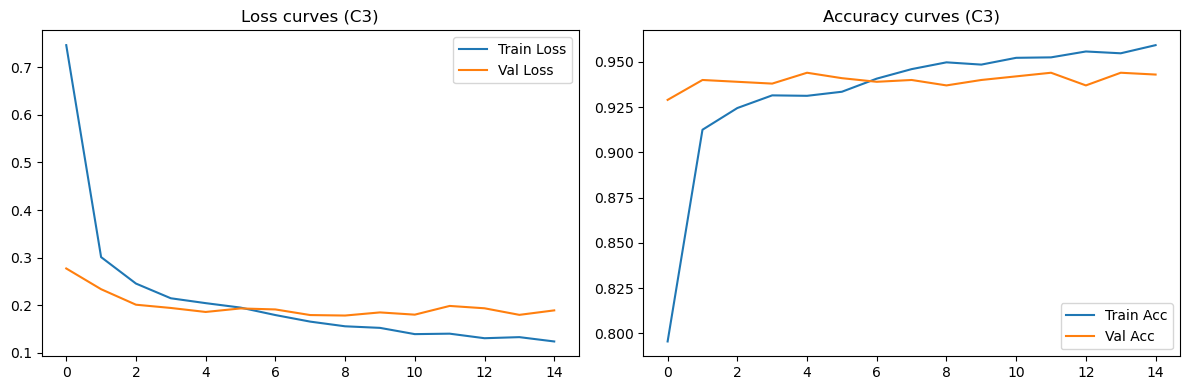

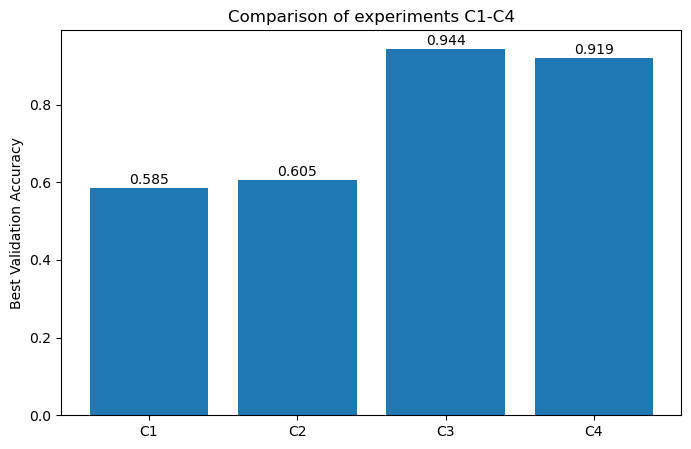

In [12]:
# Графики сравнения и кривые обучения лучшей модели
# Кривые лучшего прогона
history_best = None
if best_exp == 'C1':
    history_best = history_c1
elif best_exp == 'C2':
    history_best = history_c2
elif best_exp == 'C3':
    history_best = history_c3
else:
    history_best = history_c4

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(history_best['train_loss'], label='Train Loss')
ax[0].plot(history_best['val_loss'], label='Val Loss')
ax[0].set_title(f'Loss curves ({best_exp})')
ax[0].legend()
ax[1].plot(history_best['train_acc'], label='Train Acc')
ax[1].plot(history_best['val_acc'], label='Val Acc')
ax[1].set_title(f'Accuracy curves ({best_exp})')
ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'classification_curves_best.png'))
plt.show()

# Сравнение C1-C4
fig, ax = plt.subplots(figsize=(8,5))
names = list(results_cls.keys())
values = list(results_cls.values())
ax.bar(names, values)
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Comparison of experiments C1-C4')
for i, v in enumerate(values):
    ax.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.savefig(os.path.join(figures_dir, 'classification_compare.png'))
plt.show()

## Часть B: детекция (Pascal VOC)

### Загрузка данных и модели

In [13]:
# Загрузка датасета Pascal VOC Detection (используем validation split для тестирования)
voc_root = './data/VOCdevkit'
voc_dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True)

# Для демонстрации возьмём несколько изображений
num_samples = 10
indices = list(range(len(voc_dataset)))
random.shuffle(indices)
sample_indices = indices[:num_samples]
samples = [voc_dataset[i] for i in sample_indices]

# Загружаем предобученную модель Faster R-CNN
model_det = models.detection.fasterrcnn_resnet50_fpn(weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
model_det.to(device)
model_det.eval()

# Функция для инференса
def detect_boxes(model, image, score_threshold=0.3):
    with torch.no_grad():
        image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)
        predictions = model(image_tensor)[0]
    # Фильтруем по score
    keep = predictions['scores'] > score_threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    return boxes, scores, labels

In [14]:
# Функция для вычисления IoU
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

# Функция для сопоставления предсказаний с ground truth (IoU>=0.5)
def match_predictions(pred_boxes, gt_boxes, iou_thresh=0.5):
    matched_preds = []
    used_gt = set()
    for i, pbox in enumerate(pred_boxes):
        best_iou = 0
        best_gt = -1
        for j, gbox in enumerate(gt_boxes):
            iou = compute_iou(pbox, gbox)
            if iou > best_iou and j not in used_gt:
                best_iou = iou
                best_gt = j
        if best_iou >= iou_thresh:
            matched_preds.append((i, best_gt, best_iou))
            used_gt.add(best_gt)
    return matched_preds

# Функция для извлечения ground truth boxes из аннотации VOC
def extract_gt_boxes(annotation):
    objects = annotation['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
    boxes = []
    for obj in objects:
        bndbox = obj['bndbox']
        box = [int(bndbox['xmin']), int(bndbox['ymin']), int(bndbox['xmax']), int(bndbox['ymax'])]
        boxes.append(box)
    return boxes

In [15]:
# Функция для визуализации предсказаний
def visualize_detections(image, gt_boxes, pred_boxes, scores, labels, title, save_path=None):
    fig, ax = plt.subplots(1, figsize=(10,10))
    ax.imshow(image)
    # Ground truth (зеленые)
    for box in gt_boxes:
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, edgecolor='green', linewidth=2)
        ax.add_patch(rect)
    # Предсказания (красные)
    for box, score in zip(pred_boxes, scores):
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(box[0], box[1]-5, f'{score:.2f}', color='red', fontsize=8)
    ax.set_title(title)
    ax.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    return fig

In [16]:
# Выполним инференс для двух порогов и соберём метрики
thresholds = [0.3, 0.7]
results_det = {}

for thresh in thresholds:
    all_precisions = []
    all_recalls = []
    all_ious = []
    
    # Для визуализации выберем первые 5 изображений
    viz_indices = sample_indices[:5]
    
    for idx, (img, target) in enumerate(samples):
        # Предсказание
        pred_boxes, scores, pred_labels = detect_boxes(model_det, img, score_threshold=thresh)
        # GT boxes
        gt_boxes = extract_gt_boxes(target)
        
        # Сопоставление
        matches = match_predictions(pred_boxes, gt_boxes, iou_thresh=0.5)
        tp = len(matches)
        fp = len(pred_boxes) - tp
        fn = len(gt_boxes) - tp
        
        precision = tp / (tp + fp) if (tp+fp)>0 else 0
        recall = tp / (tp + fn) if (tp+fn)>0 else 0
        all_precisions.append(precision)
        all_recalls.append(recall)
        
        # Mean IoU для сопоставленных предсказаний
        ious = [iou for _, _, iou in matches]
        mean_iou = np.mean(ious) if ious else 0
        all_ious.append(mean_iou)
        
        # Визуализация для первых 5
        if idx in viz_indices:
            save_path = os.path.join(figures_dir, f'detection_{thresh}_{idx}.png')
            visualize_detections(img, gt_boxes, pred_boxes, scores, pred_labels, f'Threshold={thresh}', save_path)
    
    results_det[thresh] = {
        'precision': np.mean(all_precisions),
        'recall': np.mean(all_recalls),
        'mean_iou': np.mean(all_ious)
    }
    print(f"Threshold {thresh}: Precision={results_det[thresh]['precision']:.3f}, Recall={results_det[thresh]['recall']:.3f}, Mean IoU={results_det[thresh]['mean_iou']:.3f}")

Threshold 0.3: Precision=0.535, Recall=1.000, Mean IoU=0.856
Threshold 0.7: Precision=0.754, Recall=0.878, Mean IoU=0.797


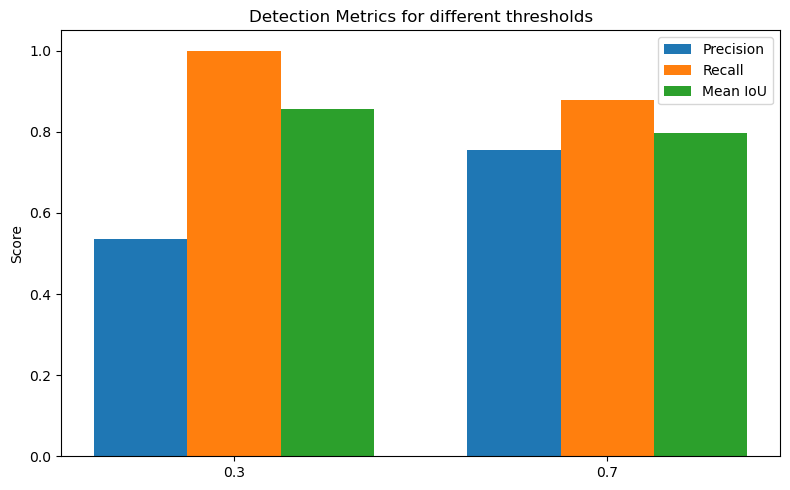

In [17]:
# Сохраняем метрики в график
fig, ax = plt.subplots(figsize=(8,5))
thresh_str = [str(t) for t in thresholds]
prec = [results_det[t]['precision'] for t in thresholds]
rec = [results_det[t]['recall'] for t in thresholds]
iou = [results_det[t]['mean_iou'] for t in thresholds]

x = np.arange(len(thresholds))
width = 0.25
ax.bar(x - width, prec, width, label='Precision')
ax.bar(x, rec, width, label='Recall')
ax.bar(x + width, iou, width, label='Mean IoU')
ax.set_xticks(x)
ax.set_xticklabels(thresh_str)
ax.set_ylabel('Score')
ax.set_title('Detection Metrics for different thresholds')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'detection_metrics.png'))
plt.show()

In [18]:
# Формирование runs.csv
runs_data = []
# Часть A
runs_data.append({
    'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
    'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_c1, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'No augmentations'
})
runs_data.append({
    'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
    'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_c2, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'With augmentations'
})
runs_data.append({
    'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
    'model_summary': 'ResNet18_head_only', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_c3, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Pretrained, frozen backbone'
})
runs_data.append({
    'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10', 'seed': 42,
    'model_summary': 'ResNet18_finetune', 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_c4, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Pretrained, finetune layer4+fc'
})
# Добавим тестовую точность лучшей модели
for row in runs_data:
    if row['experiment_id'] == best_exp:
        row['test_accuracy'] = test_acc

# Часть B
for thresh in thresholds:
    runs_data.append({
        'experiment_id': f'V{int(thresh*10)}', 'task': 'detection', 'dataset': 'PascalVOC2012', 'seed': 42,
        'model_summary': 'FasterRCNN_ResNet50_FPN', 'optimizer': None, 'lr': None, 'epochs_trained': None,
        'best_val_accuracy': None, 'test_accuracy': None, 'precision': results_det[thresh]['precision'],
        'recall': results_det[thresh]['recall'], 'mean_iou': results_det[thresh]['mean_iou'],
        'notes': f'score_threshold={thresh}'
    })

df_runs = pd.DataFrame(runs_data)
df_runs.to_csv(os.path.join(artifacts_dir, 'runs.csv'), index=False)
print("runs.csv сохранён")

runs.csv сохранён
